In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel("flights_2024_2025.xlsx")
df

,FL_DATE,AIRLINE_NAME,ORIGIN_AIRPORT,DEST_AIRPORT,DEP_DELAY,ARR_DELAY,DISTANCE,CANCELLED
0,2024-01-05,Delta Air Lines Inc.,ATL,JFK,15,20,760,0
1,2024-01-12,American Airlines Inc.,LAX,ORD,-5,-2,1744,0
2,2024-02-10,United Air Lines Inc.,SFO,SEA,10,12,679,0
3,2024-02-15,Southwest Airlines Co.,DAL,HOU,0,5,239,0
4,2024-03-03,Spirit Air Lines,ORD,MCO,25,30,986,0
5,2024-03-22,Alaska Airlines Inc.,SEA,LAS,-3,0,867,0
6,2024-04-07,JetBlue Airways,JFK,BOS,5,7,187,0
7,2024-04-15,Frontier Airlines Inc.,DEN,PHX,12,15,602,0
8,2024-05-02,Delta Air Lines Inc.,ATL,MIA,20,25,595,0
9,2024-05-18,American Airlines Inc.,ORD,DEN,8,10,888,0



#  Convert date column to datetime

In [6]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df

,FL_DATE,AIRLINE_NAME,ORIGIN_AIRPORT,DEST_AIRPORT,DEP_DELAY,ARR_DELAY,DISTANCE,CANCELLED
0,2024-01-05,Delta Air Lines Inc.,ATL,JFK,15,20,760,0
1,2024-01-12,American Airlines Inc.,LAX,ORD,-5,-2,1744,0
2,2024-02-10,United Air Lines Inc.,SFO,SEA,10,12,679,0
3,2024-02-15,Southwest Airlines Co.,DAL,HOU,0,5,239,0
4,2024-03-03,Spirit Air Lines,ORD,MCO,25,30,986,0
5,2024-03-22,Alaska Airlines Inc.,SEA,LAS,-3,0,867,0
6,2024-04-07,JetBlue Airways,JFK,BOS,5,7,187,0
7,2024-04-15,Frontier Airlines Inc.,DEN,PHX,12,15,602,0
8,2024-05-02,Delta Air Lines Inc.,ATL,MIA,20,25,595,0
9,2024-05-18,American Airlines Inc.,ORD,DEN,8,10,888,0


In [7]:
df.dtypes

FL_DATE           datetime64[ns]
AIRLINE_NAME              object
ORIGIN_AIRPORT            object
DEST_AIRPORT              object
DEP_DELAY                  int64
ARR_DELAY                  int64
DISTANCE                   int64
CANCELLED                  int64
dtype: object

# Filter for years 2024 and 2025

In [8]:
df = df[df['FL_DATE'].dt.year.isin([2024, 2025])]
df

,FL_DATE,AIRLINE_NAME,ORIGIN_AIRPORT,DEST_AIRPORT,DEP_DELAY,ARR_DELAY,DISTANCE,CANCELLED
0,2024-01-05,Delta Air Lines Inc.,ATL,JFK,15,20,760,0
1,2024-01-12,American Airlines Inc.,LAX,ORD,-5,-2,1744,0
2,2024-02-10,United Air Lines Inc.,SFO,SEA,10,12,679,0
3,2024-02-15,Southwest Airlines Co.,DAL,HOU,0,5,239,0
4,2024-03-03,Spirit Air Lines,ORD,MCO,25,30,986,0
5,2024-03-22,Alaska Airlines Inc.,SEA,LAS,-3,0,867,0
6,2024-04-07,JetBlue Airways,JFK,BOS,5,7,187,0
7,2024-04-15,Frontier Airlines Inc.,DEN,PHX,12,15,602,0
8,2024-05-02,Delta Air Lines Inc.,ATL,MIA,20,25,595,0
9,2024-05-18,American Airlines Inc.,ORD,DEN,8,10,888,0


# Drop missing values for key columns

In [9]:
df = df.dropna(subset=['DEP_DELAY', 'ARR_DELAY', 'DISTANCE'])
df

,FL_DATE,AIRLINE_NAME,ORIGIN_AIRPORT,DEST_AIRPORT,DEP_DELAY,ARR_DELAY,DISTANCE,CANCELLED
0,2024-01-05,Delta Air Lines Inc.,ATL,JFK,15,20,760,0
1,2024-01-12,American Airlines Inc.,LAX,ORD,-5,-2,1744,0
2,2024-02-10,United Air Lines Inc.,SFO,SEA,10,12,679,0
3,2024-02-15,Southwest Airlines Co.,DAL,HOU,0,5,239,0
4,2024-03-03,Spirit Air Lines,ORD,MCO,25,30,986,0
5,2024-03-22,Alaska Airlines Inc.,SEA,LAS,-3,0,867,0
6,2024-04-07,JetBlue Airways,JFK,BOS,5,7,187,0
7,2024-04-15,Frontier Airlines Inc.,DEN,PHX,12,15,602,0
8,2024-05-02,Delta Air Lines Inc.,ATL,MIA,20,25,595,0
9,2024-05-18,American Airlines Inc.,ORD,DEN,8,10,888,0


#  1. Average Departure Delay per Airline

C:\Users\user\AppData\Local\Temp\ipykernel_7260\2498768068.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_airline.values, y=avg_delay_airline.index, palette="viridis")


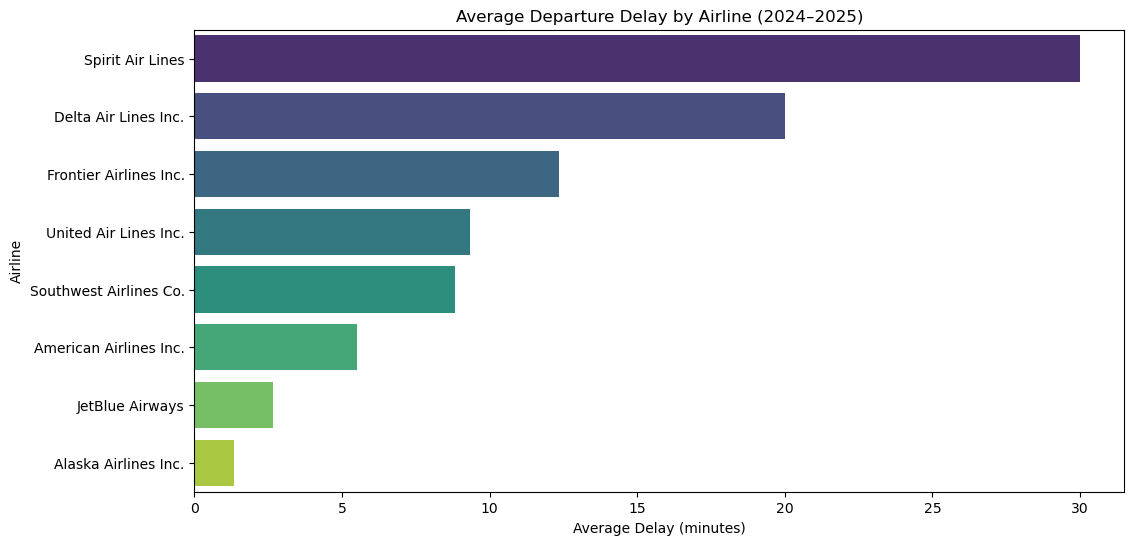

In [10]:
avg_delay_airline = df.groupby('AIRLINE_NAME')['DEP_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=avg_delay_airline.values, y=avg_delay_airline.index, palette="viridis")
plt.title("Average Departure Delay by Airline (2024–2025)")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Airline")
plt.show()

# 2. Cancellation Analysis 

C:\Users\user\AppData\Local\Temp\ipykernel_7260\1655535765.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_count.values, y=cancel_count.index, palette="rocket")


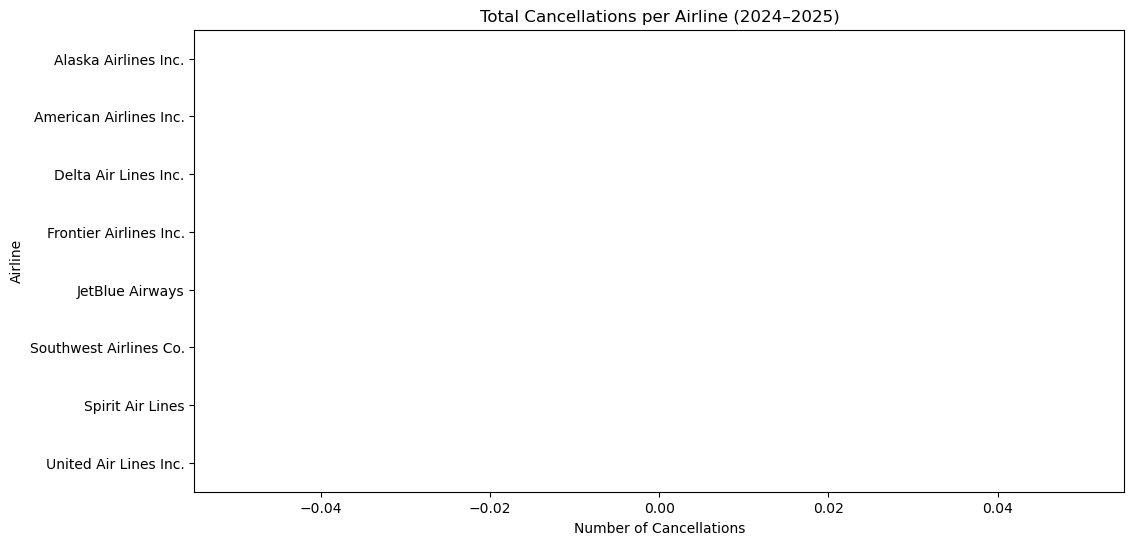

In [11]:
cancel_count = df.groupby('AIRLINE_NAME')['CANCELLED'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=cancel_count.values, y=cancel_count.index, palette="rocket")
plt.title("Total Cancellations per Airline (2024–2025)")
plt.xlabel("Number of Cancellations")
plt.ylabel("Airline")
plt.show()

# 3. Monthly Delay Heatmap by Airline

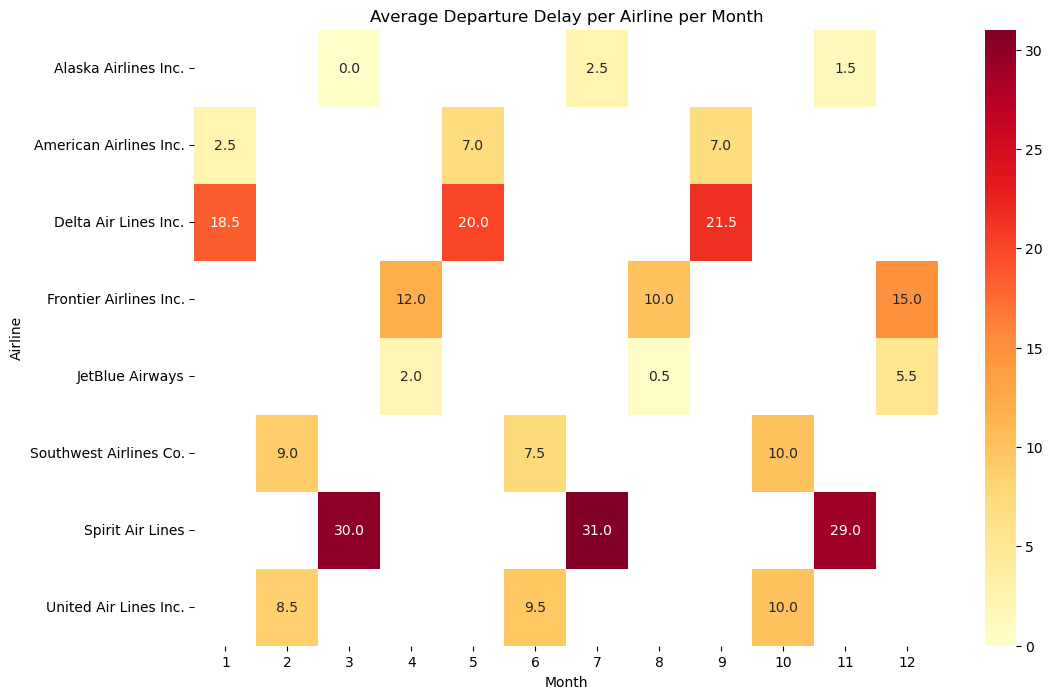

In [12]:
df['Month'] = df['FL_DATE'].dt.month
heatmap_data = df.groupby(['AIRLINE_NAME', 'Month'])['DEP_DELAY'].mean().unstack()

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Average Departure Delay per Airline per Month")
plt.ylabel("Airline")
plt.xlabel("Month")
plt.show()

# 4. Delay vs Distance Correlation

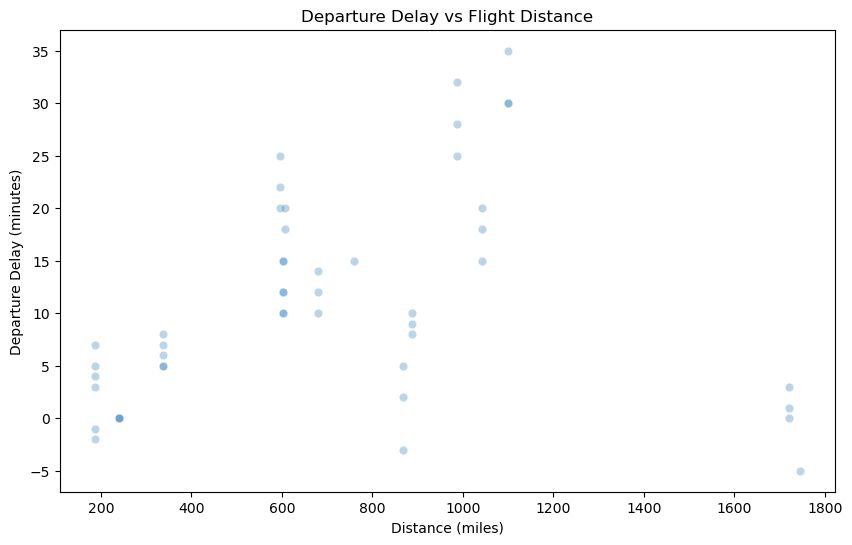

Correlation between Distance and Departure Delay: 0.19


In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='DISTANCE', y='DEP_DELAY', data=df, alpha=0.3)
plt.title("Departure Delay vs Flight Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Departure Delay (minutes)")
plt.show()

correlation = df['DISTANCE'].corr(df['DEP_DELAY'])
print(f"Correlation between Distance and Departure Delay: {correlation:.2f}")

# Top 10 Routes with Highest Average Delays

C:\Users\user\AppData\Local\Temp\ipykernel_7260\1915728380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, palette="mako")


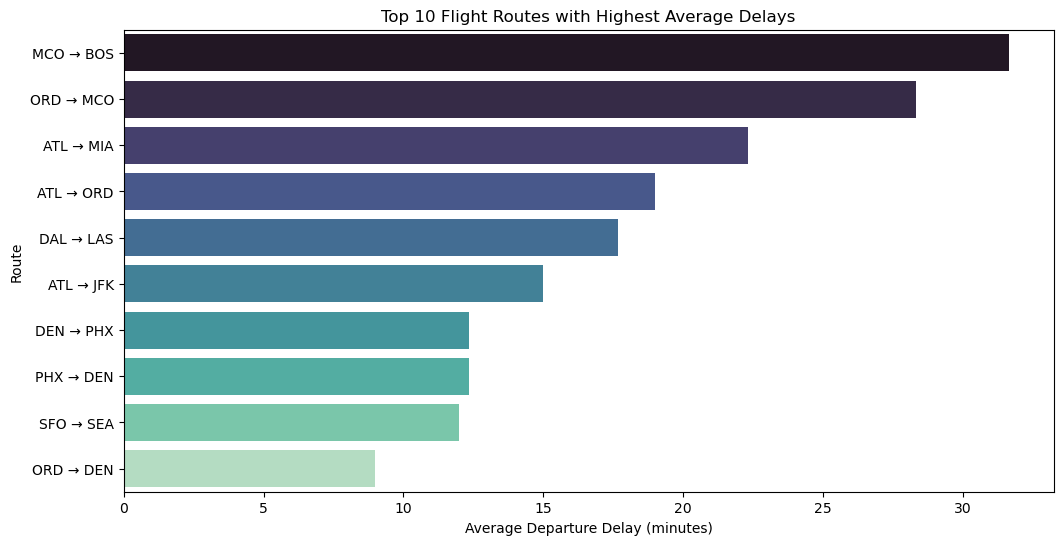

In [14]:
df['ROUTE'] = df['ORIGIN_AIRPORT'] + " → " + df['DEST_AIRPORT']
top_routes = df.groupby('ROUTE')['DEP_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index, palette="mako")
plt.title("Top 10 Flight Routes with Highest Average Delays")
plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Route")
plt.show()

# Best Routes (Least Delays)

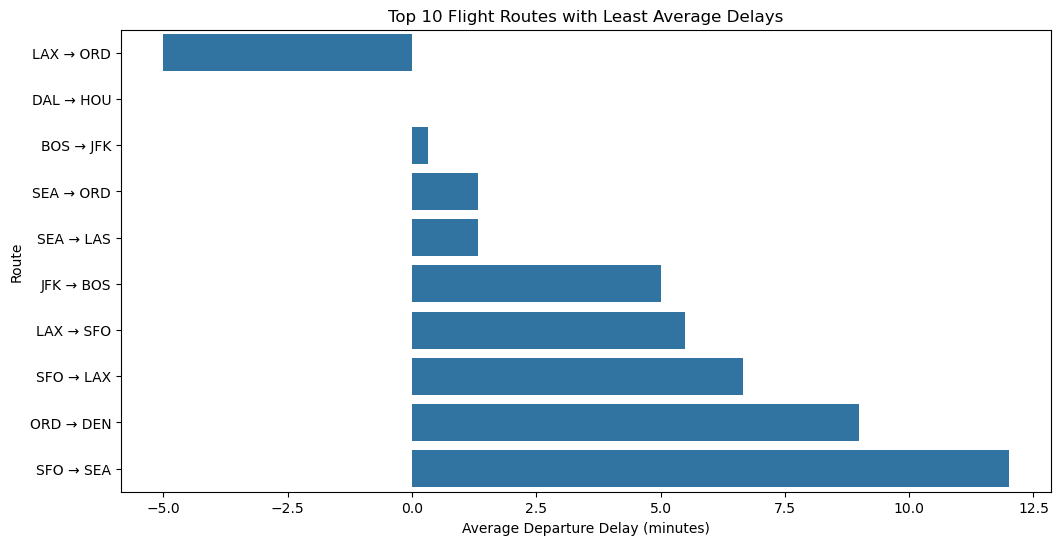

In [15]:
best_routes = (
    df.groupby('ROUTE')['DEP_DELAY']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=best_routes.values, y=best_routes.index)
plt.title("Top 10 Flight Routes with Least Average Delays")
plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Route")
plt.show()

# On-Time Performance (%) by Airline

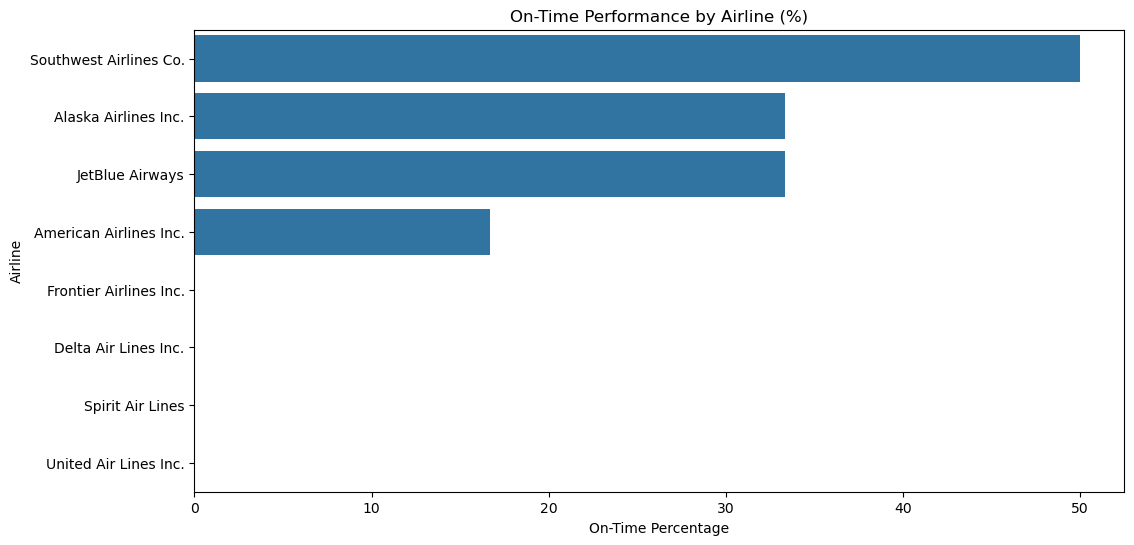

In [16]:
df['ON_TIME'] = df['DEP_DELAY'] <= 0

on_time_rate = (
    df.groupby('AIRLINE_NAME')['ON_TIME']
    .mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=on_time_rate.values, y=on_time_rate.index)
plt.title("On-Time Performance by Airline (%)")
plt.xlabel("On-Time Percentage")
plt.ylabel("Airline")
plt.show()

# Delay Severity Categories (Advanced Insight)

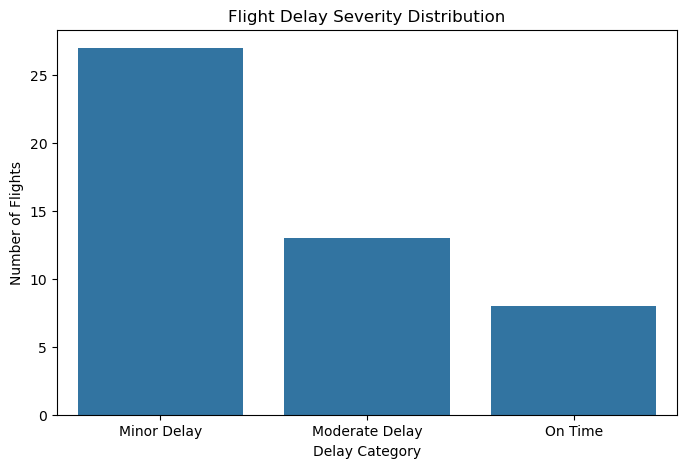

In [17]:
def delay_category(delay):
    if delay <= 0:
        return "On Time"
    elif delay <= 15:
        return "Minor Delay"
    elif delay <= 45:
        return "Moderate Delay"
    else:
        return "Severe Delay"

df['DELAY_CATEGORY'] = df['DEP_DELAY'].apply(delay_category)

delay_dist = df['DELAY_CATEGORY'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=delay_dist.index, y=delay_dist.values)
plt.title("Flight Delay Severity Distribution")
plt.xlabel("Delay Category")
plt.ylabel("Number of Flights")
plt.show()

In [18]:
df.columns

Index(['FL_DATE', 'AIRLINE_NAME', 'ORIGIN_AIRPORT', 'DEST_AIRPORT',
       'DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'CANCELLED', 'Month', 'ROUTE',
       'ON_TIME', 'DELAY_CATEGORY'],
      dtype='object')

C:\Users\user\AppData\Local\Temp\ipykernel_7260\903705955.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_delay = df.groupby('DISTANCE_TYPE')['DEP_DELAY'].mean()


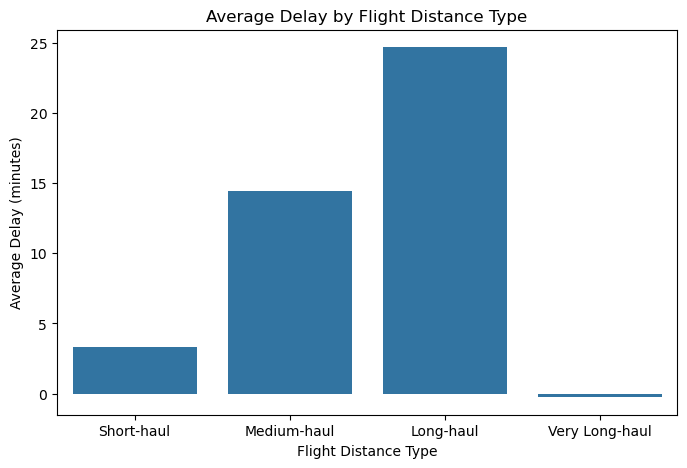

In [19]:
bins = [0, 500, 1000, 1500, 3000]
labels = ['Short-haul', 'Medium-haul', 'Long-haul', 'Very Long-haul']

df['DISTANCE_TYPE'] = pd.cut(df['DISTANCE'], bins=bins, labels=labels)

distance_delay = df.groupby('DISTANCE_TYPE')['DEP_DELAY'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=distance_delay.index, y=distance_delay.values)
plt.title("Average Delay by Flight Distance Type")
plt.xlabel("Flight Distance Type")
plt.ylabel("Average Delay (minutes)")
plt.show()

# Top Delayed Routes per Airline

In [20]:
top_routes_airline = (
    df.groupby(['AIRLINE_NAME', 'ROUTE'])['DEP_DELAY']
    .mean()
    .reset_index()
    .sort_values('DEP_DELAY', ascending=False)
    .groupby('AIRLINE_NAME')
    .head(1)
)

top_routes_airline

,AIRLINE_NAME,ROUTE,DEP_DELAY
14,Spirit Air Lines,MCO → BOS,31.666667
6,Delta Air Lines Inc.,ATL → MIA,22.333333
13,Southwest Airlines Co.,DAL → LAS,17.666667
9,Frontier Airlines Inc.,PHX → DEN,12.333333
17,United Air Lines Inc.,SFO → SEA,12.000000
4,American Airlines Inc.,ORD → DEN,9.000000
11,JetBlue Airways,JFK → BOS,5.000000
0,Alaska Airlines Inc.,SEA → LAS,1.333333
